<a href="https://colab.research.google.com/github/vicfior/Projeto-DataSUS/blob/main/03_consolidacao_pyspark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 Projeto Data Major — Risco de Letalidade Hospitalar por DRSAI no Brasil

**Disciplina:** Tópicos de Banco de Dados | Centro Universitário IESB | 2026  
**Professor:** Rodrigo Gonçalves  
**Curso:** Ciência da Computação  

---

## Motivação

O Brasil registra anualmente mais de 1 milhão de internações hospitalares por **Doenças Relacionadas ao Saneamento Ambiental Inadequado (DRSAI)**, um conjunto de enfermidades cuja transmissão está diretamente ligada à ausência ou precariedade de saneamento básico: água não tratada, esgoto a céu aberto, drenagem insuficiente e vetores que se reproduzem em condições de higiene inadequada.

Apesar de amplamente preveníveis, essas doenças continuam sendo causa relevante de morbimortalidade, especialmente nas regiões Norte e Nordeste do Brasil, onde a cobertura de saneamento é historicamente inferior à média nacional. O paradoxo é conhecido: as regiões com menor investimento em saneamento são as que mais oneram o sistema público de saúde com internações evitáveis.

---

## Pergunta de Pesquisa

> **Para doenças infecciosas reconhecidamente associadas ao saneamento inadequado (transmissão hídrica, fecal-oral e vetorial), dado o perfil de saneamento básico de uma região (cobertura de água tratada, coleta e tratamento de esgoto) e seu histórico de internações hospitalares, qual o risco preditivo (Alto / Médio / Baixo) de essa região enfrentar um pico de letalidade hospitalar nos períodos subsequentes?**

Essa pergunta combina dois eixos complementares:

- **Eixo epidemiológico:** o escopo é restrito a doenças onde a relação causal com saneamento é consolidada na literatura, FUNASA (2006), OMS e Ministério da Saúde reconhecem explicitamente leptospirose, doenças diarreicas agudas, hepatite A, helmintíases e arboviroses como DRSAI. Isso elimina a necessidade de justificar a ligação conceitual entre a doença e o saneamento.

- **Eixo preditivo regional:** o saneamento entra não como variável de contexto, mas como **feature preditiva central** do modelo. A hipótese é que regiões com menor cobertura de esgoto, maior perda na rede de água e menor adequação entre esgoto coletado e água consumida apresentam historicamente maior risco de picos de letalidade por DRSAI e que esse padrão é aprendível e generalizável.

A unidade analítica é a **macrorregião de saúde × trimestre**, escala em que o SUS planeja e aloca recursos de média e alta complexidade, e onde a decisão de intervenção em saneamento tem impacto mensurável em internações hospitalares.

---

## Objetivo

Construir um pipeline completo de dados, da coleta à modelagem, integrando registros hospitalares do **SIH-SUS** (Sistema de Informações Hospitalares do SUS) com indicadores de saneamento do **SNIS** (Sistema Nacional de Informações sobre Saneamento), para treinar um modelo de classificação supervisionada capaz de predizer o nível de risco de letalidade DRSAI por macrorregião de saúde e trimestre.

---

## Fontes de Dados

| Fonte | Sistema | Granularidade | Período | Acesso |
|---|---|---|---|---|
| SIH-SUS | DataSUS / Ministério da Saúde | Internação individual → município × mês | 2017-2019 e 2023-2024 | PySUS (FTP) |
| SNIS | Ministério das Cidades | Município × ano | 2017-2022 | Base dos Dados (BigQuery) |
| Macrorregiões de Saúde | MS / Seidigi 2024 | Município → macrorregião | — | CSV oficial |

> **Nota:** Os anos 2020-2022 foram excluídos do período de modelagem devido ao choque estrutural da pandemia de COVID-19, que distorce o padrão histórico de internações por outras causas.

---

## Escopo de Doenças — DRSAI (5 categorias)

| Categoria | CIDs | Mecanismo de transmissão |
|---|---|---|
| Fecal-oral | A00–A09, B15 | Água e alimentos contaminados por fezes |
| Leptospirose | A27 | Contato com água contaminada por urina de ratos |
| Helmintíases | B65–B83 | Larvas em solo úmido sem saneamento |
| Arboviroses | A90–A92 | Vetor (*Aedes aegypti*) em água parada |
| Malária | B50–B54 | Vetor (*Anopheles*) em coleções hídricas estagnadas |

---

## Arquitetura do Pipeline

### Extract — coleta automatizada
Fonte 1: SIH-SUS via PySUS 1.0.1 → FTP DataSUS → 1.620 arquivos Parquet\
Fonte 2: SNIS via Base dos Dados (BigQuery) → tabela br_mdr_snis.municipio_agua_esgoto\
Fonte 3: Tabela de macrorregiões MS/Seidigi 2024 (CSV) → 5.571 municípios, 121 macros\
Volume bruto: ~30 GB (SIH) | Anos: 2017-2019 + 2023-2024 | COVID 2020-2022 excluído

**O que foi feito:** automatização da coleta de três fontes de dados públicos via script Python. O SIH-SUS foi baixado pela biblioteca PySUS através de FTP do DataSUS — 1.620 arquivos Parquet cobrindo 27 UFs × 5 anos × 12 meses. O SNIS foi obtido via Base dos Dados usando SQL no BigQuery. A tabela de macrorregiões veio do portal MS/Seidigi em CSV.

**Por que essas fontes:** SIH-SUS registra toda internação hospitalar financiada pelo SUS — é a fonte oficial de morbidade hospitalar no Brasil. SNIS é o sistema nacional de indicadores de saneamento — único com granularidade municipal e série histórica. Macrorregiões são a unidade de planejamento de saúde do SUS — onde decisões de alocação de recursos são tomadas.

**Por que excluir 2020-2022:** os anos da pandemia de COVID-19 distorcem estruturalmente o padrão de internações — tanto pelo choque direto do vírus quanto pela subnotificação e reorganização do sistema de saúde. Incluí-los contaminaria o modelo.

---

### Transform — limpeza e preparação
SIH — Filtro DRSAI (5 categorias oficiais FUNASA/MS):\
Fecal-oral: A00-A09, B15 | Leptospirose: A27 | Helmintíases: B65-B83\
Arboviroses: A90-A92 (dengue, zika, chikungunya) | Malária: B50-B54\
Resultado: 1.335.340 internações DRSAI (de ~100M totais no SIH)\
SNIS — 5 indicadores de saneamento selecionados:\
Cobertura água (IN055), coleta esgoto (IN015), tratamento esgoto\
Perdas na rede, adequação esgoto/água consumida (IN046)\
Decisão: ausência de rede = imputa 0 (não NaN) — ausência é dado\
Carry forward: SNIS 2022 → 2023-2024 (variação interanual menor que 1 p.p.)\
Normalização de tipos: MORTE string→int (bug PySUS corrigido)\
Merge macrorregiões: código IBGE 7 dígitos (SNIS) → 6 dígitos (trunca DV): 0% de perda

**Filtro DRSAI:** das ~100 milhões de internações no SIH bruto, filtramos pelas 5 categorias de Doenças Relacionadas ao Saneamento Ambiental Inadequado conforme classificação oficial do Ministério da Saúde. Resultado: 1.335.340 internações, ou cerca de 1,3% do total — coerente com a literatura epidemiológica.

**Por que 5 categorias:** fecal-oral e leptospirose têm transmissão direta por água/esgoto contaminado. Helmintíases se desenvolvem em solo úmido sem saneamento. Arboviroses (dengue, zika, chikungunya) usam o Aedes aegypti como vetor, que se reproduz em água parada — causada por ausência de abastecimento regular. Malária usa o Anopheles, que se reproduz em coleções hídricas estagnadas — associadas à ausência de drenagem. Todas têm relação causal documentada com saneamento inadequado na literatura FUNASA 2006.

**Decisão do SNIS:** municípios sem dado de coleta de esgoto recebem valor 0, não valor ausente. A razão: ausência de rede formal de esgoto é um dado epidemiológico — significa que a população depende de fossa ou despejo clandestino. Para o modelo de risco DRSAI, isso é informação, não lacuna.

**Carry forward 2022→2023-2024:** o SNIS foi encerrado em 2023 e substituído pelo SINISA. Como o SNIS 2023-2024 não existe, usamos 2022 como proxy — decisão sustentada empiricamente: a variação interanual dos indicadores foi menor que 1 ponto percentual no período 2017-2022.

**Correção do bug de tipos:** o campo MORTE vinha como string no Parquet do PySUS, não como inteiro. A comparação == 1 retornava sempre False, zerando todas as taxas de letalidade silenciosamente. Corrigido com conversão explícita de tipos antes de qualquer cálculo.

---

### Load — armazenamento em Parquet (Apache)
Ferramenta: PySpark 3.x no Google Colab + Google Drive como data lake\
Agregação: PySpark groupBy + pivot → município × mês × categoria DRSAI\
Dataset analítico final (join SIH × SNIS):\
183.096 linhas | 24 colunas | granularidade: município × mês\
Features SIH: n_internacoes, n_obitos, letalidade, idade_media, por categoria\
Features SNIS: 5 indicadores de saneamento por município × ano\
Justificativa Parquet: compressão Snappy, leitura colunar, compatível PySpark/pandas

**Formato Parquet:** foi usado Parquet com compressão Snappy por três razões: leitura colunar (carrega só as colunas necessárias, não a linha inteira), compatibilidade nativa com PySpark, e compressão eficiente para dados com muitos valores repetidos (UFs, CIDs, categorias).

**PySpark:** usado na fase de consolidação e agregação porque permite leitura paralela de 1.619 arquivos Parquet particionados por UF/ano, sem carregar tudo na RAM simultaneamente. Seguimos o mesmo padrão demonstrado pelo professor no notebook CFEM — pandas para limpeza inicial, PySpark para transformações em escala.

**Dataset analítico final:** 183.096 linhas × 24 colunas, no nível município × mês. Cada linha representa um município num determinado mês, com métricas de internações DRSAI (volume, óbitos, letalidade, distribuição por categoria) e indicadores de saneamento daquele ano (cobertura de água, coleta e tratamento de esgoto, perdas na rede). É o dataset que vai para o modelo.

---

## Resumo de volumes

| Métrica | Valor |
|---|---|
| Arquivos baixados do DataSUS | 1.620 (27 UFs × 12 meses × 5 anos) |
| Internações DRSAI identificadas | 1.335.340 (~1,3% do total SIH) |
| Categorias de doenças | 5 categorias, 39 prefixos CID-10 |
| Municípios com DRSAI no período | 5.529 municípios |
| Macrorregiões cobertas | 121 de 121 (100%) |
| Dataset analítico final | 183.096 linhas × 24 colunas |
| Perda no merge município → macrorregião | 0% |

In [ ]:
# Monta Drive
from google.colab import drive
import os
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content/drive/MyDrive/projeto_drsai/data/interim

 sih_drsai   sih_drsai_spark  'sih_drsai_spark (1)'   snis


In [ ]:
!ls /content/drive/MyDrive/projeto_drsai/data/processed

analitico_municipio_mes.parquet		  sih_drsai_municipio_trimestre.parquet
sih_drsai_consolidado			  snis_macrorregiao_2017_2024.parquet
sih_drsai_filtrado_consolidado		  snis_municipio_2017_2024.parquet
sih_drsai_macrorregiao_trimestre.parquet


In [ ]:
# Instala PySpark
!pip install pyspark -q

In [ ]:
# Verifica PySpark
import pyspark
print(f"✅ PySpark {pyspark.__version__}")

✅ PySpark 4.0.2


In [ ]:
from pyspark.sql import SparkSession

spark = (SparkSession.builder
    .appName("ETL_DRSAI_Macrorregiao")
    .config("spark.driver.memory", "8g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print(f"✅ Spark iniciado: {spark.version}")

✅ Spark iniciado: 4.0.2


In [ ]:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from pathlib import Path

# Testa com um arquivo só pois estava dando erro de timestamp do pandas com o pyspark
arquivo_teste = "/content/drive/MyDrive/projeto_drsai/data/interim/sih_drsai/2017/sih_drsai_AC_2017_01.parquet"

# Lê com pandas (funciona — pandas suporta nanosegundos)
df_teste = pd.read_parquet(arquivo_teste)
print("Colunas:", list(df_teste.columns))
print("DT_INTER dtype:", df_teste["DT_INTER"].dtype)
print("DT_SAIDA dtype:", df_teste["DT_SAIDA"].dtype)

# Remove as colunas problemáticas e salva em formato compatível com Spark
df_teste_sem_dt = df_teste.drop(columns=["DT_INTER", "DT_SAIDA"])

# Salva numa pasta de teste
Path("/content/spark_test/").mkdir(exist_ok=True)
df_teste_sem_dt.to_parquet(
    "/content/spark_test/teste.parquet",
    index=False,
    coerce_timestamps="ms"   # ← força microsegundos, compatível com Spark
)

# Tenta ler com Spark
df_spark_teste = spark.read.parquet("/content/spark_test/")
print(f"\n✅ Spark leu com sucesso: {df_spark_teste.count()} linhas")
df_spark_teste.printSchema()

Colunas: ['ANO_CMPT', 'MES_CMPT', 'DT_INTER', 'DT_SAIDA', 'MUNIC_RES', 'UF_ZI', 'DIAG_PRINC', 'DIAG_SECUN', 'MORTE', 'IDADE', 'COD_IDADE', 'SEXO', 'RACA_COR', 'DIAS_PERM', 'VAL_TOT', 'UTI_MES_TO', 'N_AIH', 'categoria_drsai']
DT_INTER dtype: datetime64[ns]
DT_SAIDA dtype: datetime64[ns]

✅ Spark leu com sucesso: 118 linhas
root
 |-- ANO_CMPT: integer (nullable = true)
 |-- MES_CMPT: integer (nullable = true)
 |-- MUNIC_RES: string (nullable = true)
 |-- UF_ZI: string (nullable = true)
 |-- DIAG_PRINC: string (nullable = true)
 |-- DIAG_SECUN: string (nullable = true)
 |-- MORTE: byte (nullable = true)
 |-- IDADE: integer (nullable = true)
 |-- COD_IDADE: byte (nullable = true)
 |-- SEXO: byte (nullable = true)
 |-- RACA_COR: byte (nullable = true)
 |-- DIAS_PERM: integer (nullable = true)
 |-- VAL_TOT: double (nullable = true)
 |-- UTI_MES_TO: integer (nullable = true)
 |-- N_AIH: string (nullable = true)
 |-- categoria_drsai: string (nullable = true)



In [ ]:
from pathlib import Path
import pandas as pd
import gc
import time

PATH_INTERIM = Path("/content/drive/MyDrive/projeto_drsai/data/interim/sih_drsai/")
PATH_SPARK   = Path("/content/drive/MyDrive/projeto_drsai/data/interim/sih_drsai_spark/")

COLUNAS_REMOVER = ["DT_INTER", "DT_SAIDA"]

arquivos = sorted(PATH_INTERIM.glob("**/*.parquet"))
print(f"Arquivos a converter: {len(arquivos)}")

inicio = time.time()
erros = []

for i, arq in enumerate(arquivos, 1):
    # Recria estrutura de subpastas (2017/, 2018/, etc.)
    relativo = arq.relative_to(PATH_INTERIM)
    destino  = PATH_SPARK / relativo
    destino.parent.mkdir(parents=True, exist_ok=True)

    # Idempotente
    if destino.exists():
        continue

    try:
        df = pd.read_parquet(arq)
        df = df.drop(columns=COLUNAS_REMOVER, errors="ignore")
        df.to_parquet(destino, index=False, coerce_timestamps="ms")
        del df
        gc.collect()
    except Exception as e:
        erros.append((arq.name, str(e)))

    if i % 100 == 0:
        elapsed = time.time() - inicio
        eta = (len(arquivos) - i) * (elapsed / i)
        print(f"[{i}/{len(arquivos)}] | ETA: {eta/60:.1f} min | Erros: {len(erros)}")

print(f"\n✅ Conversão concluída!")
print(f"   Total:  {len(arquivos)}")
print(f"   Erros:  {len(erros)}")
if erros:
    print(f"   Arquivos com erro: {[e[0] for e in erros[:5]]}")

Arquivos a converter: 1619

✅ Conversão concluída!
   Total:  1619
   Erros:  0


In [ ]:
# Confirma que o Spark lê a pasta nova sem erros
df_sih = (spark.read
    .option("recursiveFileLookup", "true")
    .parquet(str(PATH_SPARK))
)

print(f"✅ Spark OK!")
df_sih.limit(1).show()
df_sih.printSchema()

✅ Spark OK!
+--------+--------+---------+------+----------+----------+-----+-----+---------+----+--------+---------+-------+----------+-------------+---------------+
|ANO_CMPT|MES_CMPT|MUNIC_RES| UF_ZI|DIAG_PRINC|DIAG_SECUN|MORTE|IDADE|COD_IDADE|SEXO|RACA_COR|DIAS_PERM|VAL_TOT|UTI_MES_TO|        N_AIH|categoria_drsai|
+--------+--------+---------+------+----------+----------+-----+-----+---------+----+--------+---------+-------+----------+-------------+---------------+
|    2017|       2|   210630|210000|      A085|      0000|    0|    7|        3|   1|       3|        3|  340.9|         0|2117100084286|     fecal_oral|
+--------+--------+---------+------+----------+----------+-----+-----+---------+----+--------+---------+-------+----------+-------------+---------------+

root
 |-- ANO_CMPT: integer (nullable = true)
 |-- MES_CMPT: integer (nullable = true)
 |-- MUNIC_RES: string (nullable = true)
 |-- UF_ZI: string (nullable = true)
 |-- DIAG_PRINC: string (nullable = true)
 |-- DIAG_

In [ ]:
# Definição da função e dicionário expandido (v2)
PREFIXOS_DRSAI_V2 = {
    'fecal_oral': [
        'A00','A01','A02','A03','A04','A05',
        'A06','A07','A08','A09','B15'
    ],
    'leptospirose': ['A27'],
    'helmintiase': [
        'B65','B66','B67','B68','B69','B70',
        'B71','B72','B73','B74','B75','B76',
        'B77','B78','B79','B80','B81','B82','B83'
    ],
    'arboviral': ['A90','A91','A92'],
    'malaria':   ['B50','B51','B52','B53','B54'],
}

def categorizar_drsai_v2(cid: str) -> str:
    if not isinstance(cid, str) or len(cid) < 3:
        return 'fora_escopo'
    prefixo = cid[:3]
    for categoria, lista in PREFIXOS_DRSAI_V2.items():
        if prefixo in lista:
            return categoria
    return 'fora_escopo'

print(f"✅ categorizar_drsai_v2 carregada")
print(f"   Categorias: {list(PREFIXOS_DRSAI_V2.keys())}")
print(f"   Total de prefixos: {sum(len(v) for v in PREFIXOS_DRSAI_V2.values())}")

✅ categorizar_drsai_v2 carregada
   Categorias: ['fecal_oral', 'leptospirose', 'helmintiase', 'arboviral', 'malaria']
   Total de prefixos: 39


In [ ]:
# Spike v2 — valida novas categorias antes de reprocessar
import pyarrow.parquet as pq
import pandas as pd

COLUNAS_SIH = [
    'ANO_CMPT','MES_CMPT','MUNIC_RES','UF_ZI',
    'DIAG_PRINC','DIAG_SECUN','MORTE',
    'IDADE','COD_IDADE','SEXO','RACA_COR',
    'DIAS_PERM','VAL_TOT','UTI_MES_TO','N_AIH',
]

amostras = [
    ('/content/drive/MyDrive/projeto_drsai/data/raw/sih/2023/sih_rd_AM_2023_01.parquet', 'AM/2023-01'),
    ('/content/drive/MyDrive/projeto_drsai/data/raw/sih/2023/sih_rd_SP_2023_01.parquet', 'SP/2023-01'),
]

for caminho, label in amostras:
    df = pq.read_table(caminho, columns=COLUNAS_SIH).to_pandas()
    df['categoria_drsai'] = df['DIAG_PRINC'].apply(categorizar_drsai_v2)
    df_drsai = df[df['categoria_drsai'] != 'fora_escopo']

    print(f"\n{label}: {len(df):,} internações totais → {len(df_drsai):,} DRSAI")
    print(f"  Distribuição: {df_drsai['categoria_drsai'].value_counts().to_dict()}")
    print(f"  Taxa DRSAI: {100*len(df_drsai)/len(df):.2f}%")

    del df, df_drsai


AM/2023-01: 18,155 internações totais → 582 DRSAI
  Distribuição: {'fecal_oral': 488, 'arboviral': 67, 'malaria': 20, 'helmintiase': 6, 'leptospirose': 1}
  Taxa DRSAI: 3.21%

SP/2023-01: 210,225 internações totais → 1,215 DRSAI
  Distribuição: {'fecal_oral': 829, 'arboviral': 328, 'leptospirose': 38, 'helmintiase': 15, 'malaria': 5}
  Taxa DRSAI: 0.58%


In [ ]:
# ============================================================
# ETAPA 1 — Filtro DRSAI v2 (salva local primeiro)
# ============================================================
import pyarrow.parquet as pq
import pandas as pd
from pathlib import Path
import gc, time

# Paths
PATH_RAW    = Path('/content/drive/MyDrive/projeto_drsai/data/raw/sih/')
PATH_LOCAL  = Path('/content/sih_drsai_v2/')  # LOCAL — rápido
PATH_LOCAL.mkdir(parents=True, exist_ok=True)

COLUNAS_SIH = [
    'ANO_CMPT','MES_CMPT','MUNIC_RES','UF_ZI',
    'DIAG_PRINC','DIAG_SECUN','MORTE',
    'IDADE','COD_IDADE','SEXO','RACA_COR',
    'DIAS_PERM','VAL_TOT','UTI_MES_TO','N_AIH',
]

# Categorias v2 (já definidas acima)
PREFIXOS_DRSAI_V2 = {
    'fecal_oral':  ['A00','A01','A02','A03','A04','A05','A06','A07','A08','A09','B15'],
    'leptospirose':['A27'],
    'helmintiase': ['B65','B66','B67','B68','B69','B70','B71','B72','B73','B74',
                    'B75','B76','B77','B78','B79','B80','B81','B82','B83'],
    'arboviral':   ['A90','A91','A92'],
    'malaria':     ['B50','B51','B52','B53','B54'],
}

def categorizar_drsai_v2(cid):
    if not isinstance(cid, str) or len(cid) < 3:
        return 'fora_escopo'
    p = cid[:3]
    for cat, lista in PREFIXOS_DRSAI_V2.items():
        if p in lista:
            return cat
    return 'fora_escopo'

# Lista arquivos brutos (exclui spike e _tmp)
arquivos = sorted([
    a for a in PATH_RAW.glob('**/*.parquet')
    if 'spike' not in str(a) and '_tmp' not in str(a)
])
print(f"Arquivos para processar: {len(arquivos)}")

inicio = time.time()
stats = {'processado':0, 'sem_drsai':0, 'erro':0}

for i, arq in enumerate(arquivos, 1):
    relativo = arq.relative_to(PATH_RAW)
    destino  = PATH_LOCAL / relativo
    destino.parent.mkdir(parents=True, exist_ok=True)

    if destino.exists():
        stats['processado'] += 1
        continue

    try:
        df = pq.read_table(arq, columns=COLUNAS_SIH).to_pandas()
        df['categoria_drsai'] = df['DIAG_PRINC'].apply(categorizar_drsai_v2)
        df_drsai = df[df['categoria_drsai'] != 'fora_escopo'].copy()

        df_drsai.to_parquet(
            destino, index=False,
            compression='snappy',
            coerce_timestamps='ms'
        )

        status = 'sem_drsai' if len(df_drsai) == 0 else 'processado'
        stats[status] = stats.get(status, 0) + 1

        del df, df_drsai
        gc.collect()

    except Exception as e:
        stats['erro'] += 1

    if i % 100 == 0:
        elapsed = time.time() - inicio
        eta = (len(arquivos) - i) * (elapsed / i)
        print(f"[{i}/{len(arquivos)}] ✅{stats['processado']} "
              f"❌{stats['erro']} | ETA: {eta/60:.1f} min")

print(f"\n✅ Filtro v2 concluído: {stats}")

# Verifica espaço usado localmente
import shutil
uso_local = shutil.disk_usage('/content/')
print(f"Espaço local usado: {uso_local.used/1e9:.1f} GB / {uso_local.total/1e9:.1f} GB")

Arquivos para processar: 1619
[100/1619] ✅100 ❌0 | ETA: 9.3 min
[200/1619] ✅200 ❌0 | ETA: 7.3 min
[300/1619] ✅300 ❌0 | ETA: 5.9 min


KeyboardInterrupt: 

## Decisão de granularidade: município × mês

A unidade analítica final é **macrorregião × trimestre** (para o modelo),
mas o dataset é construído em **município × mês** por dois motivos:

1. **Flexibilidade:** agrupamentos mais grossos (macrorregião, trimestre)
   são deriváveis por agregação posterior — o inverso é impossível.
2. **Join com SNIS:** os indicadores de saneamento existem em granularidade
   municipal, não regional. O join precisa acontecer antes da agregação.

A coluna `cod_macrorregiao` permite agregar para macrorregião quando necessário.

In [ ]:
# ============================================================
# ETAPA 2 — Reescrita sem timestamps (local → local)
# ============================================================
PATH_SPARK_LOCAL = Path('/content/sih_drsai_spark_v2/')
PATH_SPARK_LOCAL.mkdir(parents=True, exist_ok=True)

arquivos_v2 = sorted(PATH_LOCAL.glob('**/*.parquet'))
print(f"Reescrevendo {len(arquivos_v2)} arquivos...")

for arq in arquivos_v2:
    relativo = arq.relative_to(PATH_LOCAL)
    destino  = PATH_SPARK_LOCAL / relativo
    destino.parent.mkdir(parents=True, exist_ok=True)

    if destino.exists():
        continue

    df = pd.read_parquet(arq)
    df = df.drop(columns=['DT_INTER','DT_SAIDA'], errors='ignore')
    df.to_parquet(destino, index=False,
                  compression='snappy', coerce_timestamps='ms')
    del df
    gc.collect()

print("✅ Reescrita concluída")

Reescrevendo 390 arquivos...


KeyboardInterrupt: 

In [ ]:
# ============================================================
# ETAPA 3 — PySpark: agregação município × mês + join SNIS
# ============================================================
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
    .appName("ETL_DRSAI_v2")
    .config("spark.driver.memory", "8g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

# Lê do local (rápido — sem Drive)
df_sih = (spark.read
    .option("recursiveFileLookup", "true")
    .parquet(str(PATH_SPARK_LOCAL))
)
print(f"Total internações DRSAI v2: {df_sih.count():,}")

# Macrorregiões
df_macro_pd = pd.read_csv(
    '/content/drive/MyDrive/projeto_drsai/data/raw/macrorregioes_saude_ms_seidigi_2024.csv',
    dtype={"Codigo Municipio": "string"}
).rename(columns={
    "Codigo Municipio":             "cod_municipio",
    "Codigo Macrorregiao de Saude": "cod_macrorregiao",
    "Macrorregiao de Saude":        "nome_macrorregiao",
    "Populacao Estimada IBGE 2022": "populacao_2022",
}).assign(
    populacao_2022=lambda x: (
        x["populacao_2022"].astype(str)
         .str.replace(".", "", regex=False)
         .pipe(pd.to_numeric, errors="coerce")
    )
)[["cod_municipio","cod_macrorregiao","nome_macrorregiao","populacao_2022"]]

df_macro_spark = spark.createDataFrame(df_macro_pd)

# Join com macrorregiões
df_joined = df_sih.join(
    df_macro_spark,
    df_sih["MUNIC_RES"] == df_macro_spark["cod_municipio"],
    how="left"
).filter(F.col("cod_macrorregiao").isNotNull())

# Agregação município × mês (inclui todas as 5 categorias)
df_agg = df_joined.groupBy(
    "MUNIC_RES", "cod_macrorregiao", "nome_macrorregiao",
    "ANO_CMPT", "MES_CMPT"
).agg(
    F.count(F.lit(1)).alias("n_internacoes_drsai"),
    F.sum(F.col("MORTE").cast("int")).alias("n_obitos_drsai"),
    F.avg("IDADE").alias("idade_media"),
    F.avg("DIAS_PERM").alias("permanencia_media"),
    F.sum(F.col("VAL_TOT")).alias("valor_total_drsai"),
    F.sum(F.when(F.col("categoria_drsai")=="fecal_oral",   1).otherwise(0)).alias("fecal_oral"),
    F.sum(F.when(F.col("categoria_drsai")=="leptospirose", 1).otherwise(0)).alias("leptospirose"),
    F.sum(F.when(F.col("categoria_drsai")=="helmintiase",  1).otherwise(0)).alias("helmintiase"),
    F.sum(F.when(F.col("categoria_drsai")=="arboviral",    1).otherwise(0)).alias("arboviral"),
    F.sum(F.when(F.col("categoria_drsai")=="malaria",      1).otherwise(0)).alias("malaria"),
).withColumn(
    "letalidade_drsai",
    F.when(F.col("n_internacoes_drsai") > 0,
           F.col("n_obitos_drsai") / F.col("n_internacoes_drsai")
    ).otherwise(None)
).orderBy("MUNIC_RES", "ANO_CMPT", "MES_CMPT")

# Join com SNIS
df_snis_pd = pd.read_parquet(
    '/content/drive/MyDrive/projeto_drsai/data/interim/snis_municipio_2017_2024.parquet'
)
df_snis_pd["id_municipio"] = df_snis_pd["id_municipio"].astype(str).str[:6]
df_snis_spark = spark.createDataFrame(df_snis_pd)

df_analitico = df_agg.join(
    df_snis_spark,
    (df_agg["MUNIC_RES"] == df_snis_spark["id_municipio"]) &
    (df_agg["ANO_CMPT"]  == df_snis_spark["ano"]),
    how="left"
).drop("id_municipio", "ano", "sigla_uf")

print(f"✅ Dataset analítico: {df_analitico.count():,} linhas")
print(f"   Colunas: {len(df_analitico.columns)}")

# Salva localmente primeiro
df_analitico_pd = df_analitico.toPandas()
df_analitico_pd.to_parquet("/content/analitico_final.parquet", index=False)
df_analitico_pd.to_csv("/content/analitico_final.csv", index=False)

import os
mb_pq  = os.path.getsize("/content/analitico_final.parquet") / 1e6
mb_csv = os.path.getsize("/content/analitico_final.csv") / 1e6
print(f"\n📦 Parquet: {mb_pq:.1f} MB")
print(f"📦 CSV:     {mb_csv:.1f} MB")
print(f"   Usar CSV se Parquet < 30 MB")

NameError: name 'PATH_SPARK_LOCAL' is not defined

In [ ]:
from pathlib import Path

arquivos = [
    '/content/drive/MyDrive/projeto_drsai/data/processed/sih_drsai_consolidado/',
    '/content/drive/MyDrive/projeto_drsai/data/processed/sih_drsai_filtrado_consolidado/',
    '/content/drive/MyDrive/projeto_drsai/data/processed/sih_drsai_macrorregiao_trimestre.parquet',
    '/content/drive/MyDrive/projeto_drsai/data/processed/sih_drsai_municipio_trimestre.parquet',
    '/content/drive/MyDrive/projeto_drsai/data/processed/snis_macrorregiao_2017_2024.parquet',
    '/content/drive/MyDrive/projeto_drsai/data/processed/snis_municipio_2017_2024.parquet',
    '/content/drive/MyDrive/projeto_drsai/data/processed/analitico_municipio_mes.parquet',
]

for p in arquivos:
    path = Path(p)
    if not path.exists():
        print(f"❌ NÃO EXISTE: {path.name}")
    elif path.is_dir():
        n = len(list(path.glob('*.parquet')))
        print(f"✅ DIR  {path.name:<55} {n} arquivos .parquet")
    else:
        mb = path.stat().st_size / 1e6
        print(f"✅ FILE {path.name:<55} {mb:.1f} MB")

✅ DIR  sih_drsai_consolidado                                   0 arquivos .parquet
✅ DIR  sih_drsai_filtrado_consolidado                          0 arquivos .parquet
✅ FILE sih_drsai_macrorregiao_trimestre.parquet                0.1 MB
✅ FILE sih_drsai_municipio_trimestre.parquet                   1.1 MB
✅ FILE snis_macrorregiao_2017_2024.parquet                     0.0 MB
✅ FILE snis_municipio_2017_2024.parquet                        0.7 MB
✅ FILE analitico_municipio_mes.parquet                         4.8 MB


In [ ]:
import pandas as pd

df_analitico_pd = pd.read_parquet(
    '/content/drive/MyDrive/projeto_drsai/data/processed/analitico_municipio_mes.parquet'
)
print(f"✅ Carregado: {df_analitico_pd.shape[0]:,} linhas × {df_analitico_pd.shape[1]} colunas")

✅ Carregado: 183,096 linhas × 24 colunas


### Colunas

**Colunas de identificação e localização**
1. **MUNIC_RES** — código IBGE de 6 dígitos do município de residência do paciente, não do hospital onde foi internado. Decisão metodológica importante: usamos residência porque queremos medir o risco da população de uma região, não onde os hospitais estão concentrados. Se usássemos município de internação, São Paulo e outras capitais concentrariam artificialmente as internações de toda a região.

2. **cod_macrorregiao** — código da macrorregião de saúde do MS. Derivado do município via tabela de macrorregiões MS/Seidigi 2024.

3. **nome_macrorregiao** — nome da macrorregião (ex: "Macrorregional II (Cacoal)"). Coluna descritiva, não entra no modelo.

4. **ANO_CMPT** — ano de competência da internação (2017, 2018, 2019, 2023 ou 2024). Competência significa o mês em que a internação foi faturada ao SUS, não necessariamente quando o paciente entrou.

5. **MES_CMPT** — mês de competência (1 a 12). Junto com ANO_CMPT define a granularidade temporal do dataset.

**Colunas de volume e desfecho clínico**

1. **n_internacoes_drsai** — total de internações DRSAI naquele município × mês. É a variável de exposição — quantas pessoas internaram por doença de saneamento.

2. **n_obitos_drsai** — total de óbitos registrados durante a internação (campo MORTE == 1 no SIH). Atenção: só captura óbitos intra-hospitalares. Óbitos domiciliares ou em UPA não aparecem aqui — é uma limitação documentada do SIH.

3. **letalidade_drsai** — proporção n_obitos / n_internacoes. É a variável que vai gerar o target do modelo (Alto/Médio/Baixo). Calculada como proporção, não percentagem, para facilitar operações matemáticas.

4. **idade_media** — média de idade dos pacientes internados por DRSAI naquele município × mês. Feature do modelo — regiões com população mais jovem tendem a ter perfil DRSAI diferente (diarreias em crianças são mais comuns).

5. **permanencia_media** — média de dias de internação (DIAS_PERM). Proxy de gravidade clínica — internações mais longas indicam casos mais graves ou complicações.

6. **valor_total_drsai** — soma do valor pago pelo SUS pelas internações (VAL_TOT). Útil para análise econômica — quanto o saneamento inadequado custa ao sistema de saúde.

7. **letalidade_drsai** — proporção de óbitos sobre o total de internações DRSAI naquele município × mês. Calculada como n_obitos_drsai / n_internacoes_drsai. Tipo float64, valores entre 0.0 e 1.0 (não percentagem — 0.02 significa 2% de letalidade).

   Recebe None quando n_internacoes_drsai == 0 — evita divisão por zero em meses sem internações DRSAI naquele município.

   OBSERVAÇÃO: captura apenas mortes durante a internação. Isso é uma limitação conhecida e documentada do SIH-SUS como fonte de dados.


**Colunas por categoria DRSAI**

1. **fecal_oral** — contagem de internações por transmissão fecal-oral (CIDs A00-A09, B15). Inclui diarreias, gastroenterites, hepatite A, cólera, febre tifoide. Historicamente a categoria mais volumosa — ~70-80% das DRSAI.

2. **leptospirose** — contagem de internações por leptospirose (CID A27). Doença bacteriana transmitida por contato com água contaminada por urina de ratos — muito associada a enchentes em áreas sem saneamento.

3. **helmintiase** — contagem de internações por verminoses intestinais e parasitoses (CIDs B65-B83). Inclui esquistossomose, ascaridíase, ancilostomíase. Mais prevalente em regiões rurais sem saneamento.


4. **arboviral** — contagem de internações por arboviroses (CIDs A90-A92): dengue clássica, dengue hemorrágica, chikungunya, zika. Transmitidas pelo Aedes aegypti que se reproduz em água parada.

5. **malaria** — contagem de internações por malária (CIDs B50-B54). Transmitida pelo Anopheles em coleções hídricas estagnadas. Concentrada na região amazônica.

**Colunas do SNIS (indicadores de saneamento)**

1. **indice_atendimento_total_agua** — percentual da população total do município com acesso à rede de abastecimento de água. Inclui área urbana e rural. Hipótese: menor cobertura → maior exposição a água não tratada → maior risco DRSAI.

2. **indice_coleta_esgoto** — percentual da população com coleta formal de esgoto (IN015). Municípios sem rede recebem valor 0 — ausência de rede é o dado. Hipótese: menor coleta → esgoto a céu aberto → maior risco de transmissão fecal-oral e leptospirose.

3. **indice_tratamento_esgoto** — percentual do esgoto coletado que é efetivamente tratado antes do descarte. Pode ser alto mesmo com coleta baixa — depende da capacidade da ETE. Hipótese: menor tratamento → contaminação de corpos hídricos → maior risco DRSAI.

4. **indice_perda_distribuicao_agua** — percentual de água que se perde entre a produção e o consumo final (vazamentos, ligações clandestinas). Hipótese: maior perda → pontos de contaminação na rede → maior risco.

5. **indice_esgotamento_agua_consumida** — relação entre volume de esgoto coletado e volume de água consumida (IN046). Mede o "descompasso": se uma região consome muito água mas coleta pouco esgoto, o esgoto está indo a céu aberto. Hipótese: menor índice → esgoto não tratado → maior risco DRSAI.

6. **dado_real_snis** — flag booleana. True para anos 2017-2022 (dados reais do SNIS). False para 2023-2024 (carry forward de 2022). Permite ao avaliador identificar exatamente quais observações têm dado real e quais têm suposição.

7. **populacao_atendida_agua** — número absoluto de pessoas no município com acesso à rede de abastecimento de água (não é percentual — é contagem de habitantes). Vem direto do SNIS, campo original. Útil para calcular taxas por 100 mil habitantes e para ponderar médias na agregação por macrorregião. Note o typo preservado da fonte original: "atendida" com grafia correta aqui.

8. **populacao_atentida_esgoto** — número absoluto de pessoas com acesso à coleta formal de esgoto. Atenção: essa coluna tem um erro de digitação na fonte original do SNIS — "atentida" em vez de "atendida". O Base dos Dados preservou o erro do SNIS original. Não corrigimos para manter fidelidade à fonte e rastreabilidade — se alguém for conferir no BigQuery, vai encontrar o mesmo nome. Tem <NA> em municípios sem rede de esgoto reportada.

9. **dado_real** — flag que indica se os indicadores SNIS daquela linha são dados reais ou carry forward. Valores possíveis: True para anos 2017-2022 (dados reais do SNIS), False para 2023-2024 (valores de 2022 replicados como proxy). Tipo object porque o pandas às vezes lê booleanos mistos com nulos como string — pode ser convertido com df['dado_real'].map({'True': True, 'False': False}) se necessário para o modelo.



In [ ]:
# ══════════════════════════════════════════════════════════════
# INICIALIZAÇÃO — rodar sempre ao abrir o notebook
# ══════════════════════════════════════════════════════════════
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

# 1. Dataset principal
df = pd.read_parquet(
    '/content/drive/MyDrive/projeto_drsai/data/processed/analitico_municipio_mes.parquet'
)
print(f"✅ df carregado: {df.shape[0]:,} linhas × {df.shape[1]} colunas")

# 2. Tabela de referência — nomes de municípios
_df_ibge = pd.read_csv(
    "https://raw.githubusercontent.com/kelvins/municipios-brasileiros/main/csv/municipios.csv",
    dtype={"codigo_ibge": "string"}
)
MAPA_NOME = _df_ibge.assign(cod6=_df_ibge["codigo_ibge"].str[:6]).set_index("cod6")["nome"].to_dict()
print(f"✅ MAPA_NOME carregado: {len(MAPA_NOME):,} municípios")

# 3. Mapa UF
UF_MAP = {
    '11':'RO','12':'AC','13':'AM','14':'RR','15':'PA','16':'AP','17':'TO',
    '21':'MA','22':'PI','23':'CE','24':'RN','25':'PB','26':'PE','27':'AL',
    '28':'SE','29':'BA','31':'MG','32':'ES','33':'RJ','35':'SP','41':'PR',
    '42':'SC','43':'RS','50':'MS','51':'MT','52':'GO','53':'DF',
}
print(f"✅ UF_MAP carregado: {len(UF_MAP)} UFs")

# 4. Tratamento de NaN
df_tratado = df.copy()
df_tratado["UF"] = df_tratado["MUNIC_RES"].str[:2]

cols_esgoto = [
    "indice_coleta_esgoto",
    "indice_tratamento_esgoto",
    "indice_esgotamento_agua_consumida",
]
df_tratado[cols_esgoto] = df_tratado[cols_esgoto].fillna(0)
df_tratado["populacao_atentida_esgoto"] = df_tratado["populacao_atentida_esgoto"].fillna(0)
df_tratado["sem_cobertura_snis"] = df_tratado["indice_atendimento_total_agua"].isna()

cols_imputar = ["populacao_atendida_agua", "indice_atendimento_total_agua",
                "indice_perda_distribuicao_agua"] + cols_esgoto

for col in cols_imputar:
    for grupo in [["cod_macrorregiao", "ANO_CMPT"], ["UF", "ANO_CMPT"], ["ANO_CMPT"]]:
        mediana = df_tratado.groupby(grupo)[col].transform("median")
        df_tratado[col] = df_tratado[col].fillna(mediana)

df_tratado["dado_real"] = df_tratado["dado_real"].fillna(False).astype(bool)

nans = df_tratado[cols_imputar].isna().sum().sum()
print(f"✅ df_tratado pronto — NaN restantes: {nans}")
print("\n🚀 Tudo carregado. Pode rodar as células abaixo.")

Mounted at /content/drive
✅ df carregado: 183,096 linhas × 24 colunas
✅ MAPA_NOME carregado: 5,571 municípios
✅ UF_MAP carregado: 27 UFs
✅ df_tratado pronto — NaN restantes: 0

🚀 Tudo carregado. Pode rodar as células abaixo.


/tmp/ipykernel_8052/846536937.py:53: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_tratado["dado_real"] = df_tratado["dado_real"].fillna(False).astype(bool)


In [ ]:
# ============================================================
# DIAGNÓSTICO — Dataset analítico final (município × mês)
# ============================================================
import pandas as pd

df = df_tratado  # ← era df_analitico_pd, agora usa df_tratado

# ── 1. Schema ───────────────────────────────────────────────
print("=" * 60)
print("1. SCHEMA — colunas e tipos")
print("=" * 60)
print(df.dtypes.to_string())
print(f"\nShape: {df.shape[0]:,} linhas × {df.shape[1]} colunas")

1. SCHEMA — colunas e tipos
MUNIC_RES                             object
cod_macrorregiao                       int64
nome_macrorregiao                     object
ANO_CMPT                               int32
MES_CMPT                               int32
n_internacoes_drsai                    int64
n_obitos_drsai                         int64
idade_media                          float64
permanencia_media                    float64
valor_total_drsai                    float64
fecal_oral                             int64
leptospirose                           int64
helmintiase                            int64
arboviral                              int64
malaria                                int64
letalidade_drsai                     float64
populacao_atendida_agua              float64
populacao_atentida_esgoto            float64
indice_atendimento_total_agua        float64
indice_coleta_esgoto                 float64
indice_tratamento_esgoto             float64
indice_perda_distribuicao_a

In [ ]:
# Mapa código IBGE de UF → sigla
UF_MAP = {
    '11':'RO','12':'AC','13':'AM','14':'RR','15':'PA','16':'AP','17':'TO',
    '21':'MA','22':'PI','23':'CE','24':'RN','25':'PB','26':'PE','27':'AL',
    '28':'SE','29':'BA','31':'MG','32':'ES','33':'RJ','35':'SP','41':'PR',
    '42':'SC','43':'RS','50':'MS','51':'MT','52':'GO','53':'DF',
}

# Mapa código IBGE (6 dígitos) → nome do município
url = "https://raw.githubusercontent.com/kelvins/municipios-brasileiros/main/csv/municipios.csv"
df_ibge = pd.read_csv(url, dtype={"codigo_ibge": "string"})
df_ibge["cod6"] = df_ibge["codigo_ibge"].str[:6]
mapa_nome = df_ibge.set_index("cod6")["nome"].to_dict()

In [ ]:
# ── 2. PRIMEIRAS LINHAS — com filtro de ano/mês ─────────────
print("\n" + "=" * 60)
print("2. PRIMEIRAS LINHAS — filtradas")
print("=" * 60)

ANO_FILTRO = 2019
MES_FILTRO = 4

# Mapa código IBGE de UF → sigla
UF_MAP = {
    '11':'RO','12':'AC','13':'AM','14':'RR','15':'PA','16':'AP','17':'TO',
    '21':'MA','22':'PI','23':'CE','24':'RN','25':'PB','26':'PE','27':'AL',
    '28':'SE','29':'BA','31':'MG','32':'ES','33':'RJ','35':'SP','41':'PR',
    '42':'SC','43':'RS','50':'MS','51':'MT','52':'GO','53':'DF',
}

df_filtrado = df_tratado[df_tratado["ANO_CMPT"] == ANO_FILTRO].copy()
if MES_FILTRO:
    df_filtrado = df_filtrado[df_filtrado["MES_CMPT"] == MES_FILTRO]

df_filtrado.insert(2, "nome_municipio", df_filtrado["MUNIC_RES"].map(MAPA_NOME))

print(f"Filtro: ANO={ANO_FILTRO}, MES={MES_FILTRO or 'todos'} → {len(df_filtrado):,} linhas")
print()
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
print(df_filtrado.head(50).to_string(index=False))


2. PRIMEIRAS LINHAS — filtradas
Filtro: ANO=2019, MES=4 → 3,327 linhas

MUNIC_RES  cod_macrorregiao           nome_municipio nome_macrorregiao  ANO_CMPT  MES_CMPT  n_internacoes_drsai  n_obitos_drsai  idade_media  permanencia_media  valor_total_drsai  fecal_oral  leptospirose  helmintiase  arboviral  malaria  letalidade_drsai  populacao_atendida_agua  populacao_atentida_esgoto  indice_atendimento_total_agua  indice_coleta_esgoto  indice_tratamento_esgoto  indice_perda_distribuicao_agua  indice_esgotamento_agua_consumida  dado_real UF  sem_cobertura_snis
   354170              3532                    Quatá            RRAS11      2019         4                    1               0     1.000000           2.000000             340.90           1             0            0          0        0          0.000000                  13129.0                    13062.0                          93.05                100.00                    100.00                           20.29                     

In [ ]:
# ── 3. Contagem por categoria DRSAI ─────────────────────────
print("\n" + "=" * 60)
print("3. TOTAIS POR CATEGORIA DRSAI")
print("=" * 60)
categorias = ["fecal_oral", "leptospirose", "helmintiase", "arboviral", "malaria"]
for cat in categorias:
    if cat in df_tratado.columns:
        total = df[cat].sum()
        pct   = 100 * total / df["n_internacoes_drsai"].sum()
        print(f"  {cat:<15} {total:>10,.0f}  ({pct:.1f}%)")
    else:
        print(f"  {cat:<15} ← coluna ausente!")

print(f"\n  {'TOTAL DRSAI':<15} {df['n_internacoes_drsai'].sum():>10,.0f}")


3. TOTAIS POR CATEGORIA DRSAI
  fecal_oral         986,778  (74.0%)
  leptospirose        11,163  (0.8%)
  helmintiase          5,777  (0.4%)
  arboviral          319,964  (24.0%)
  malaria             10,289  (0.8%)

  TOTAL DRSAI      1,333,971


In [ ]:
# ── 4. Checagem do join SNIS ────────────────────────────────
print("\n" + "=" * 60)
print("4. CHECAGEM DO JOIN SNIS")
print("=" * 60)

col_snis = "indice_coleta_esgoto"

if col_snis in df_tratado.columns:
    com_snis    = df_tratado[col_snis].notna().sum()
    sem_snis    = df_tratado[col_snis].isna().sum()
    pct_cobert  = 100 * com_snis / len(df)
    print(f"  Com dado SNIS : {com_snis:>10,}  ({pct_cobert:.1f}%)")
    print(f"  Sem dado SNIS : {sem_snis:>10,}  ({100-pct_cobert:.1f}%)")

    print("\n  Cobertura SNIS por ano:")
    print(
        df.groupby("ANO_CMPT")[col_snis]
          .apply(lambda x: f"{x.notna().sum():,} / {len(x):,}  "
                           f"({100*x.notna().mean():.1f}%)")
          .to_string()
    )
else:
    print(f"  Coluna '{col_snis}' não encontrada — join pode não ter ocorrido.")
    print(f"  Colunas disponíveis: {[c for c in df_tratado.columns if 'indice' in c.lower()]}")


4. CHECAGEM DO JOIN SNIS
  Com dado SNIS :    183,096  (100.0%)
  Sem dado SNIS :          0  (0.0%)

  Cobertura SNIS por ano:
ANO_CMPT
2017    36,738 / 36,738  (100.0%)
2018    36,205 / 36,205  (100.0%)
2019    38,033 / 38,033  (100.0%)
2023    32,868 / 32,868  (100.0%)
2024    39,252 / 39,252  (100.0%)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

df_tratado = pd.read_parquet(
    '/content/drive/MyDrive/projeto_drsai/data/processed/analitico_municipio_mes.parquet'
)
print(f"✅ Carregado: {df_tratado.shape[0]:,} linhas × {df_tratado.shape[1]} colunas")

✅ Carregado: 183,096 linhas × 24 colunas


## CORREÇÕES

Confirmação do n_obitos_drsai: soma de óbitos no município em um mês

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_tratado = pd.read_parquet(
    '/content/drive/MyDrive/projeto_drsai/data/processed/analitico_municipio_mes.parquet'
)

print("=" * 50)
print("CONFIRMAÇÃO: n_obitos_drsai")
print("=" * 50)
print(f"\nValores únicos (primeiros 20): {sorted(df['n_obitos_drsai'].unique())[:20]}")
print(f"Valor máximo: {df_tratado['n_obitos_drsai'].max()}")
print(f"Valor mínimo: {df_tratado['n_obitos_drsai'].min()}")
print(f"\nDistribuição dos valores mais frequentes:")
print(df_tratado['n_obitos_drsai'].value_counts().head(10).to_string())
print(f"\nLinhas com 0 óbitos : {(df_tratado['n_obitos_drsai']==0).sum():,} ({100*(df['n_obitos_drsai']==0).mean():.1f}%)")
print(f"Linhas com ≥1 óbito : {(df_tratado['n_obitos_drsai']>=1).sum():,} ({100*(df['n_obitos_drsai']>=1).mean():.1f}%)")

CONFIRMAÇÃO: n_obitos_drsai

Valores únicos (primeiros 20): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(17), np.int64(18), np.int64(20), np.int64(24), np.int64(33)]
Valor máximo: 43
Valor mínimo: 0

Distribuição dos valores mais frequentes:
n_obitos_drsai
0    171115
1     10363
2      1105
3       262
4       100
5        42
6        31
7        20
8        13
9         9

Linhas com 0 óbitos : 171,115 (93.5%)
Linhas com ≥1 óbito : 11,981 (6.5%)


In [ ]:
# Confirmar n_obitos_drsai > 1
df_obitos = df_tratado[df_tratado['n_obitos_drsai'] > 1].copy()
df_obitos.insert(1, 'nome_municipio', df_obitos['MUNIC_RES'].map(MAPA_NOME))

print(f"Registros com n_obitos_drsai > 1: {len(df_obitos):,}")
print(f"Representa {100*len(df_obitos)/len(df_tratado):,.1f}% do total\n")

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
print(df_obitos.sort_values('n_obitos_drsai', ascending=False).head(20).to_string(index=False))

Registros com n_obitos_drsai > 1: 1,618
Representa 0.9% do total

MUNIC_RES nome_municipio  cod_macrorregiao         nome_macrorregiao  ANO_CMPT  MES_CMPT  n_internacoes_drsai  n_obitos_drsai  idade_media  permanencia_media  valor_total_drsai  fecal_oral  leptospirose  helmintiase  arboviral  malaria  letalidade_drsai  populacao_atendida_agua  populacao_atentida_esgoto  indice_atendimento_total_agua  indice_coleta_esgoto  indice_tratamento_esgoto  indice_perda_distribuicao_agua  indice_esgotamento_agua_consumida dado_real
   355030      São Paulo              3521                     RRAS6      2024         5                 2072              43    37.935328           3.672780         1046211.24         223             5            2       1842        0          0.020753               11371086.0                 11144442.0                          99.29                 75.24                     97.14                           30.07                              73.08     False
   530010 

In [ ]:
print("=" * 50)
print("ESTATÍSTICA DESCRITIVA — df_filtrado")
print("=" * 50)

cols_numericas = [
    'n_internacoes_drsai', 'n_obitos_drsai', 'idade_media',
    'permanencia_media', 'valor_total_drsai', 'fecal_oral',
    'leptospirose', 'helmintiase', 'arboviral', 'malaria',
    'letalidade_drsai', 'populacao_atendida_agua',
    'populacao_atentida_esgoto', 'indice_atendimento_total_agua',
    'indice_coleta_esgoto', 'indice_tratamento_esgoto',
    'indice_perda_distribuicao_agua', 'indice_esgotamento_agua_consumida'
]

desc = df_tratado[cols_numericas].describe(percentiles=[.25, .50, .75, .95]).T
desc['cv'] = desc['std'] / desc['mean']  # coeficiente de variação

pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
print(desc.to_string())

ESTATÍSTICA DESCRITIVA — df_filtrado
                                       count      mean        std    min      25%       50%       75%        95%          max     cv
n_internacoes_drsai               183096.000     7.286     21.144  1.000    1.000     3.000     7.000     26.000     2304.000  2.902
n_obitos_drsai                    183096.000     0.082      0.435  0.000    0.000     0.000     0.000      1.000       43.000  5.289
idade_media                       183096.000    32.159     21.930  0.000   14.333    29.727    45.750     75.000       99.000  0.682
permanencia_media                 183096.000     3.528      3.153  0.000    2.000     3.000     4.000      7.750      244.000  0.894
valor_total_drsai                 183096.000  3107.281  11705.215 40.380  378.850  1022.700  2760.763  11001.580  1553444.180  3.767
fecal_oral                        183096.000     5.389     13.020  0.000    1.000     2.000     5.000     20.000      523.000  2.416
leptospirose                    

In [ ]:
for col in ['n_internacoes_drsai', 'n_obitos_drsai', 'arboviral', 'malaria']:
    idx = df_tratado[col].idxmax()
    linha = df_tratado.loc[idx]
    print(f"\n{col} = {df[col].max()}")
    print(f"  → {linha['nome_macrorregiao']} | {linha['MUNIC_RES']} | {linha['ANO_CMPT']}/{linha['MES_CMPT']}")


n_internacoes_drsai = 2304
  → DISTRITO FEDERAL | 530010 | 2024/3

n_obitos_drsai = 43
  → RRAS6 | 355030 | 2024/5

arboviral = 2121
  → DISTRITO FEDERAL | 530010 | 2024/3

malaria = 46
  → MACRO-RORAIMA | 140010 | 2023/1


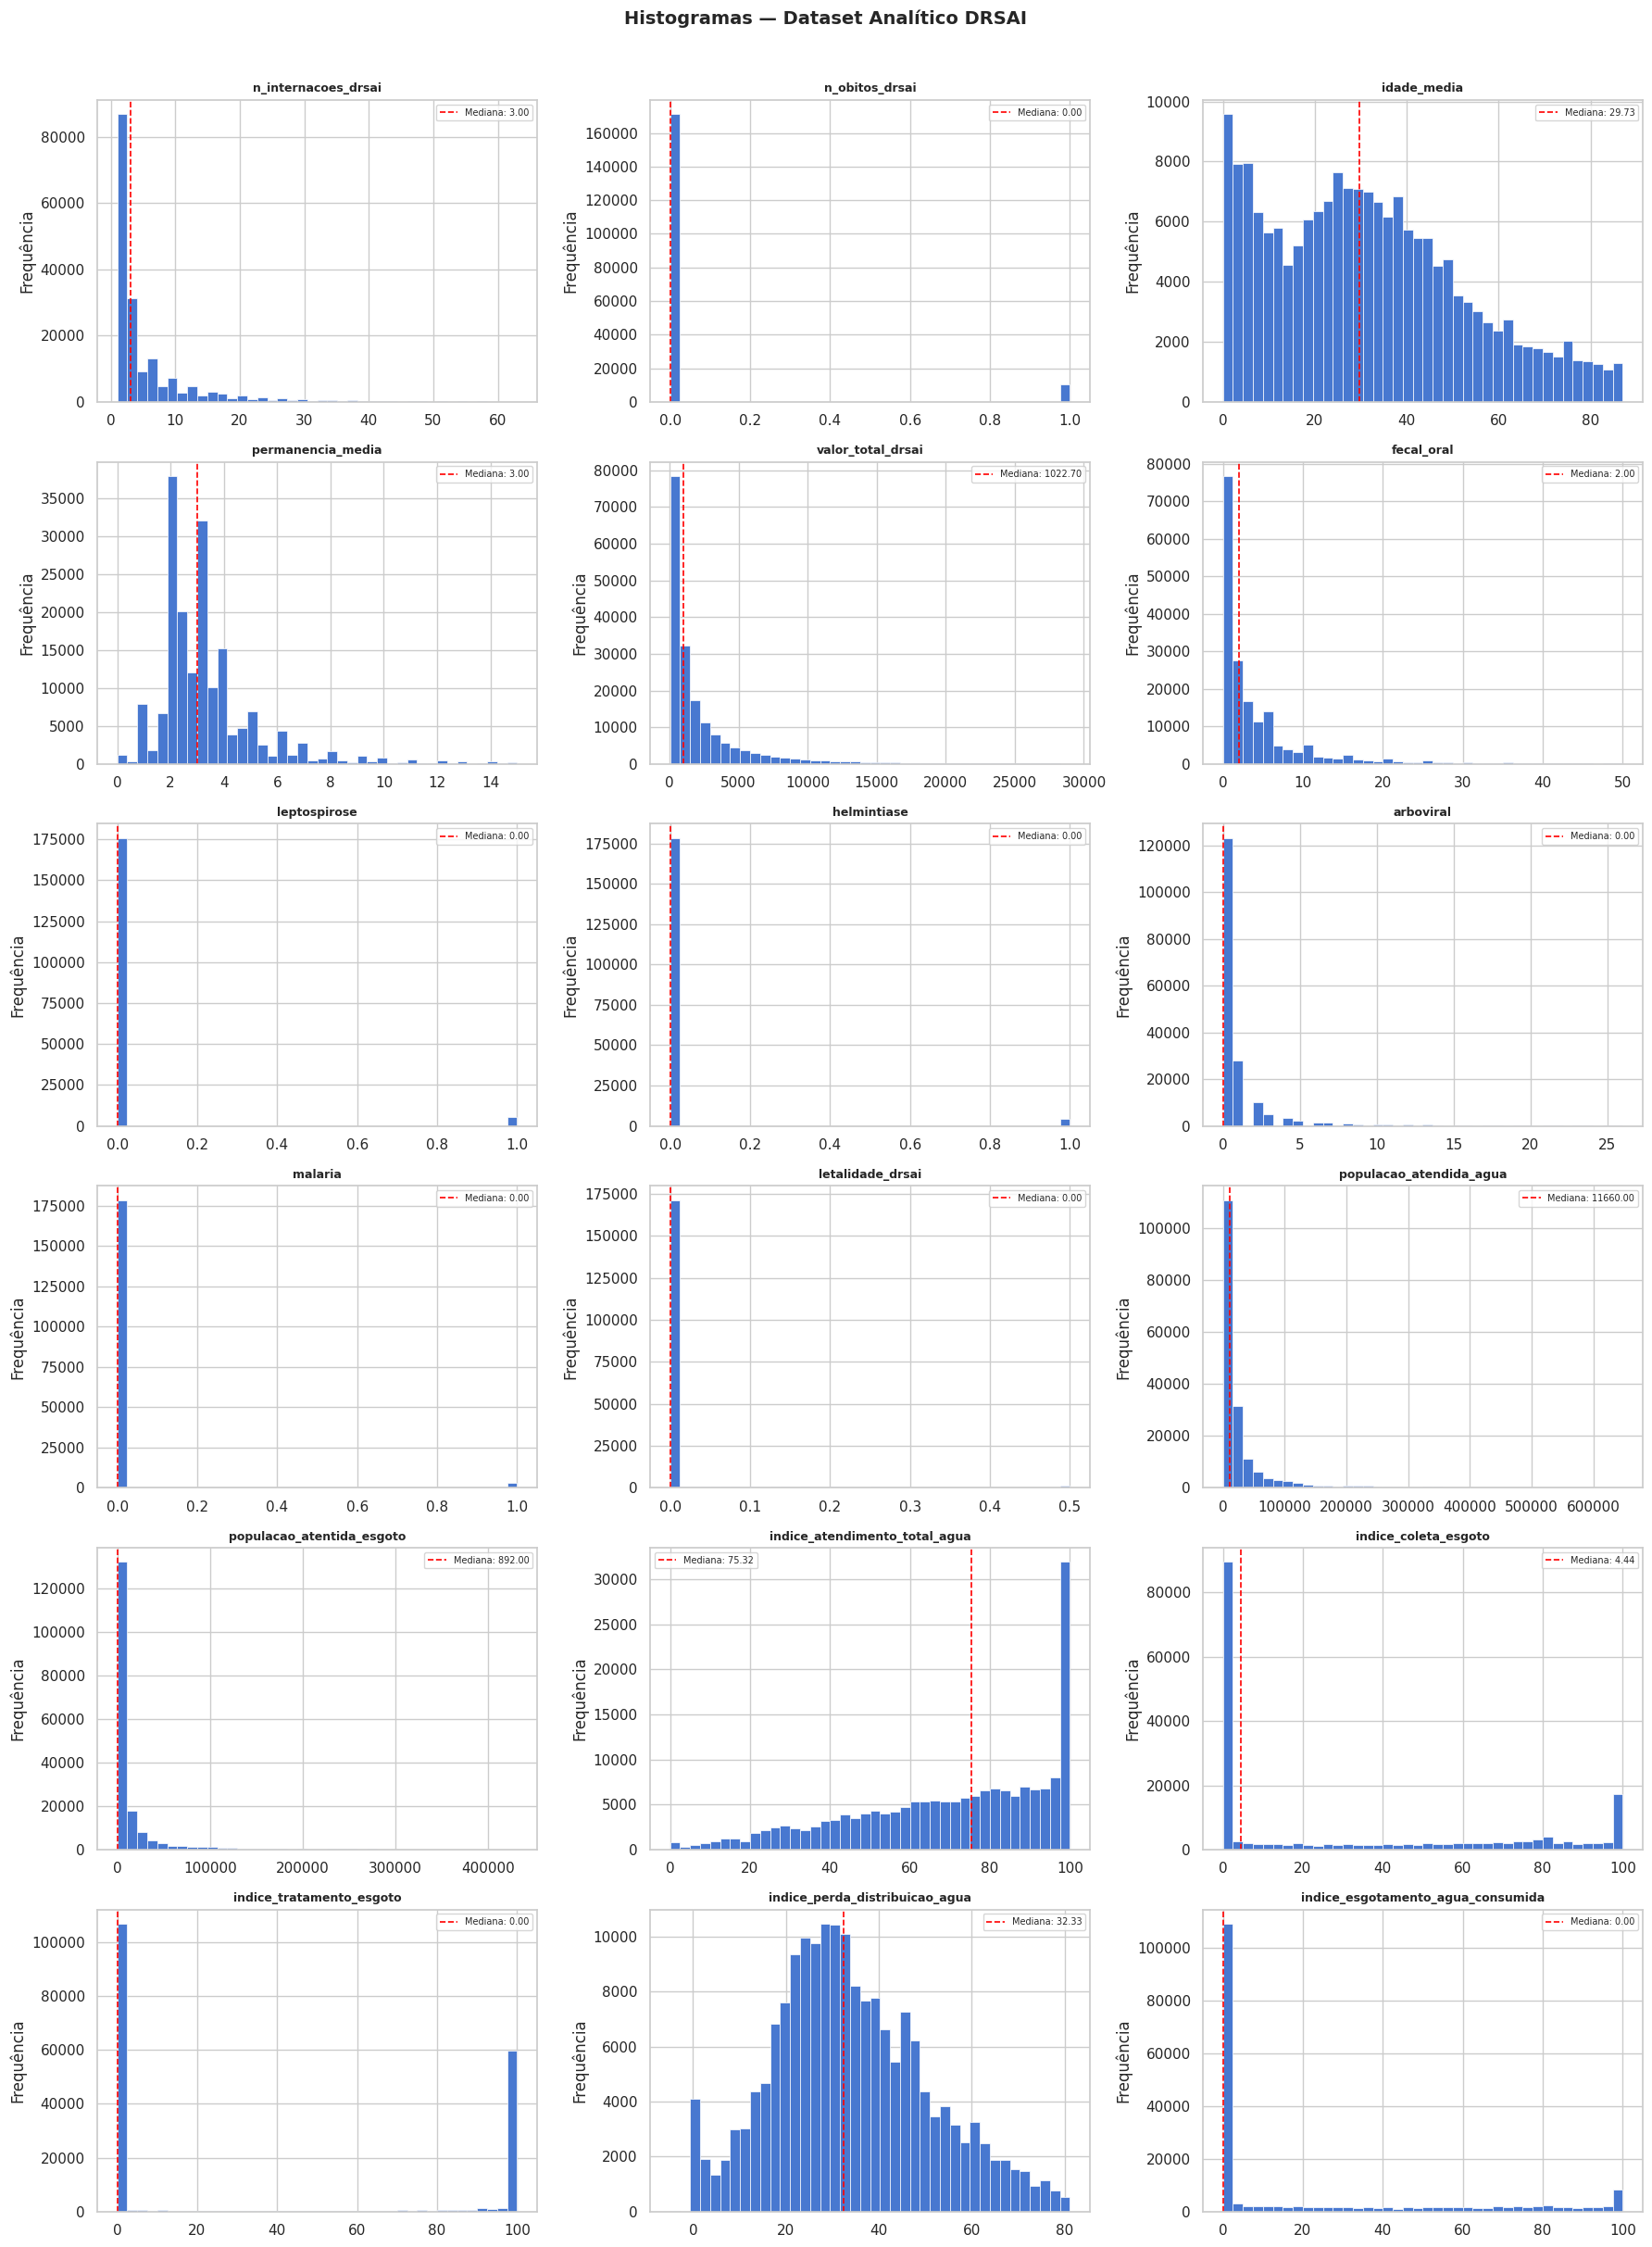

Histogramas salvos.


In [ ]:
fig, axes = plt.subplots(6, 3, figsize=(18, 24))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    dados = df[col].dropna()

    p99 = dados.quantile(0.99)
    dados_viz = dados[dados <= p99]

    ax.hist(dados_viz, bins=40, color=sns.color_palette("muted")[0],
            edgecolor='white', linewidth=0.5)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Frequência')

    mediana = dados.median()
    ax.axvline(mediana, color='red', linestyle='--', linewidth=1.2,
               label=f'Mediana: {mediana:.2f}')
    ax.legend(fontsize=7)

for j in range(len(cols_numericas), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Histogramas — Dataset Analítico DRSAI",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/projeto_drsai/eda_histogramas.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Histogramas salvos.")

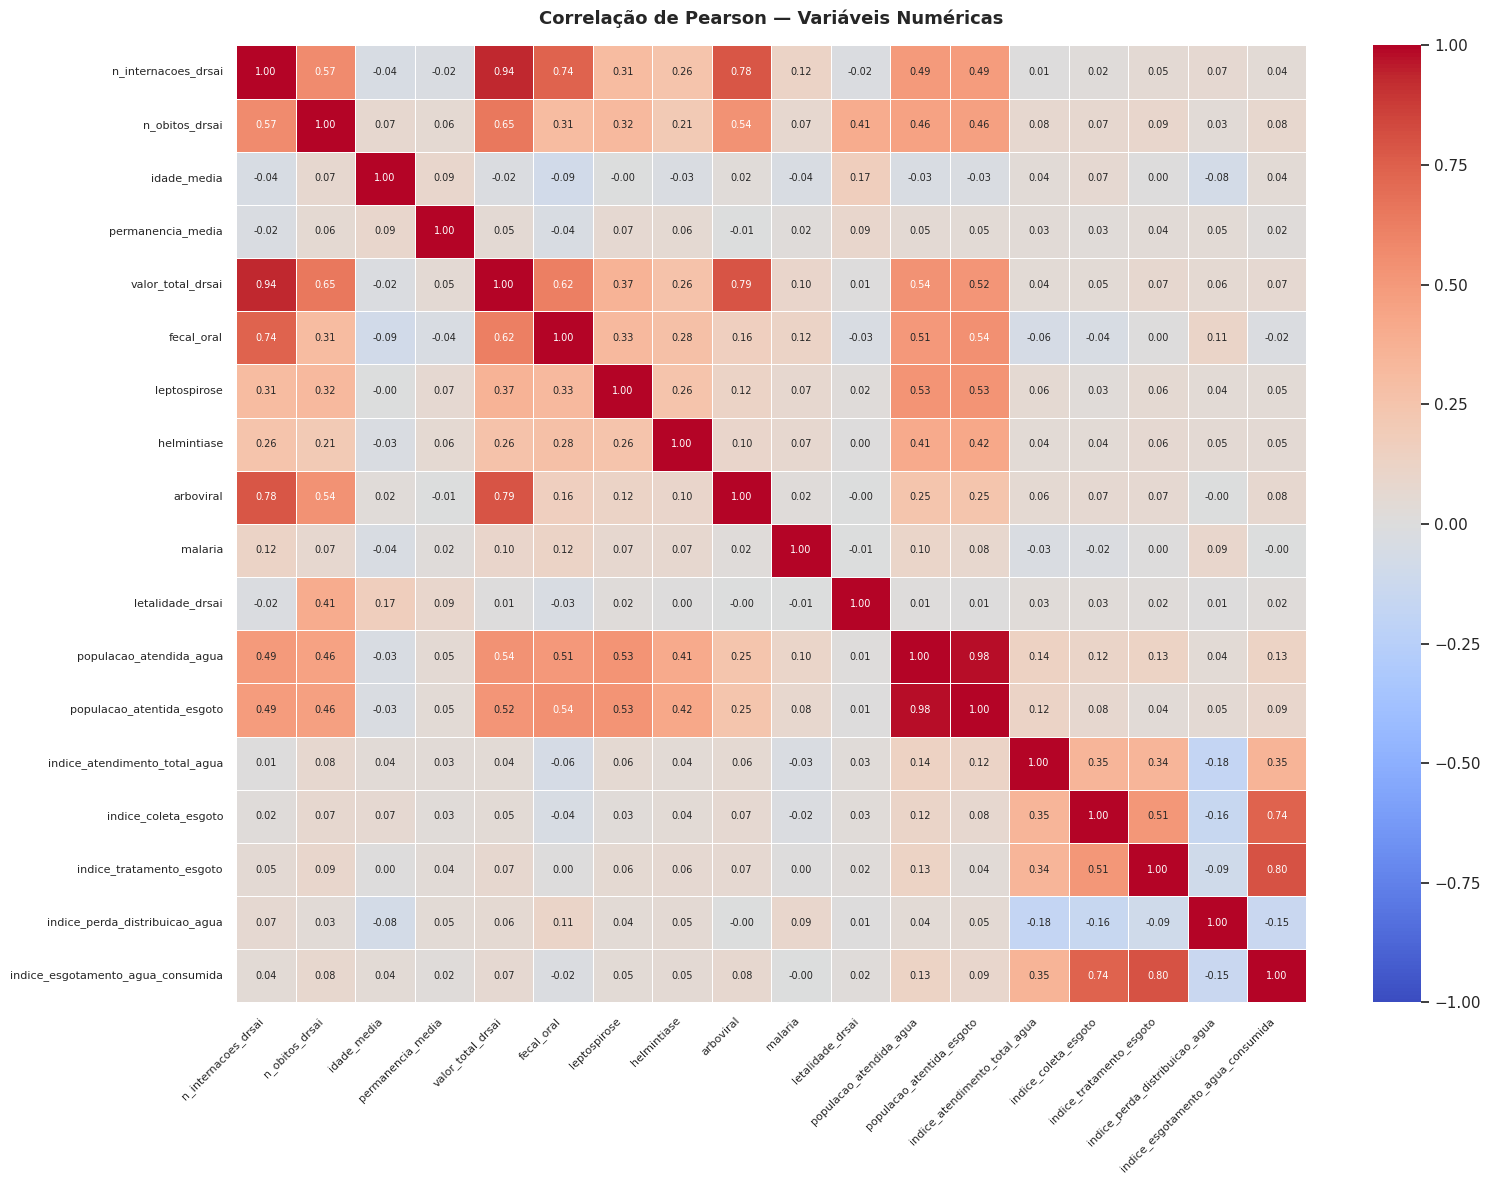


Top correlações com letalidade_drsai:
n_obitos_drsai                      0.406
idade_media                         0.171
permanencia_media                   0.086
fecal_oral                          0.032
indice_coleta_esgoto                0.028
indice_atendimento_total_agua       0.026
n_internacoes_drsai                 0.023
indice_tratamento_esgoto            0.019
indice_esgotamento_agua_consumida   0.018
leptospirose                        0.016


In [ ]:
fig, ax = plt.subplots(figsize=(16, 12))

corr = df_tratado[cols_numericas].corr(method='pearson')

mascara = corr.copy()
sns.heatmap(
    corr,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    ax=ax
)
ax.set_title("Correlação de Pearson — Variáveis Numéricas",
             fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/projeto_drsai/eda_correlacao_pearson.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nTop correlações com letalidade_drsai:")
print(corr['letalidade_drsai'].drop('letalidade_drsai')
          .abs().sort_values(ascending=False)
          .head(10).to_string())

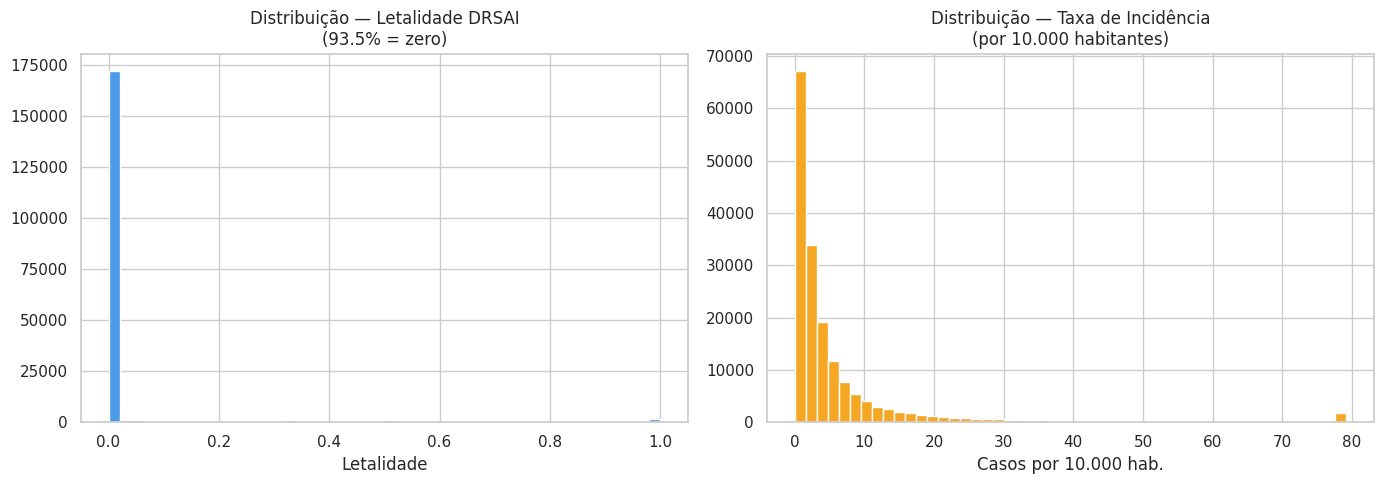

Zeros em letalidade:  93.5%
Zeros em incidência:  0.0%


In [ ]:
# Compara distribuição de letalidade vs incidência
df_tratado["taxa_incidencia"] = (
    df_tratado["n_internacoes_drsai"] /
    df_tratado["populacao_atendida_agua"].replace(0, pd.NA)
    * 10000
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_tratado["letalidade_drsai"].hist(bins=50, ax=axes[0], color="#4C9BE8")
axes[0].set_title("Distribuição — Letalidade DRSAI\n(93.5% = zero)")
axes[0].set_xlabel("Letalidade")
df_tratado["taxa_incidencia"].dropna().clip(upper=df_tratado["taxa_incidencia"].quantile(0.99)).hist(
    bins=50, ax=axes[1], color="#F5A623"
)
axes[1].set_title("Distribuição — Taxa de Incidência\n(por 10.000 habitantes)")
axes[1].set_xlabel("Casos por 10.000 hab.")

plt.tight_layout()
plt.show()

print(f"Zeros em letalidade:  {(df_tratado['letalidade_drsai']==0).mean():.1%}")
print(f"Zeros em incidência:  {(df_tratado['taxa_incidencia']==0).mean():.1%}")

In [ ]:
import numpy as np

# Recria taxa_incidencia com np.nan em vez de pd.NA
df_tratado["taxa_incidencia"] = (
    df_tratado["n_internacoes_drsai"] /
    df_tratado["populacao_atendida_agua"].replace(0, np.nan)
    * 10000
)

cols_numericas = [
    'taxa_incidencia', 'idade_media', 'permanencia_media',
    'fecal_oral', 'leptospirose', 'helmintiase', 'arboviral', 'malaria',
    'indice_atendimento_total_agua', 'indice_coleta_esgoto',
    'indice_tratamento_esgoto', 'indice_perda_distribuicao_agua',
    'indice_esgotamento_agua_consumida'
]

print("Correlação de Pearson com taxa_incidencia:")
corr = df_tratado[cols_numericas].corr(method='pearson')
print(
    corr['taxa_incidencia']
    .drop('taxa_incidencia')
    .abs()
    .sort_values(ascending=False)
    .to_string()
)

Correlação de Pearson com taxa_incidencia:
indice_perda_distribuicao_agua      0.084
indice_atendimento_total_agua       0.035
fecal_oral                          0.029
indice_coleta_esgoto                0.012
indice_tratamento_esgoto            0.012
indice_esgotamento_agua_consumida   0.010
permanencia_media                   0.006
idade_media                         0.003
leptospirose                        0.002
helmintiase                         0.002
malaria                             0.000
arboviral                           0.000


In [ ]:
# Agrega por município × ano para reduzir ruído sazonal
df_municipio_ano = (
    df_tratado.groupby(["MUNIC_RES", "ANO_CMPT"])
    .agg(
        taxa_incidencia_media  = ("taxa_incidencia", "mean"),
        indice_atendimento_total_agua     = ("indice_atendimento_total_agua", "mean"),
        indice_coleta_esgoto              = ("indice_coleta_esgoto", "mean"),
        indice_tratamento_esgoto          = ("indice_tratamento_esgoto", "mean"),
        indice_perda_distribuicao_agua    = ("indice_perda_distribuicao_agua", "mean"),
        indice_esgotamento_agua_consumida = ("indice_esgotamento_agua_consumida", "mean"),
        idade_media        = ("idade_media", "mean"),
        permanencia_media  = ("permanencia_media", "mean"),
    )
    .reset_index()
)

print(f"Shape após agregação: {df_municipio_ano.shape[0]:,} linhas")
print()

cols_corr = [
    'taxa_incidencia_media', 'indice_atendimento_total_agua',
    'indice_coleta_esgoto', 'indice_tratamento_esgoto',
    'indice_perda_distribuicao_agua', 'indice_esgotamento_agua_consumida',
    'idade_media', 'permanencia_media'
]

corr = df_municipio_ano[cols_corr].corr(method='pearson')
print("Correlação de Pearson com taxa_incidencia_media (município × ano):")
print(
    corr['taxa_incidencia_media']
    .drop('taxa_incidencia_media')
    .abs()
    .sort_values(ascending=False)
    .to_string()
)

Shape após agregação: 25,791 linhas

Correlação de Pearson com taxa_incidencia_media (município × ano):
indice_perda_distribuicao_agua      0.077
indice_atendimento_total_agua       0.031
indice_coleta_esgoto                0.010
indice_tratamento_esgoto            0.010
indice_esgotamento_agua_consumida   0.008
permanencia_media                   0.008
idade_media                         0.004


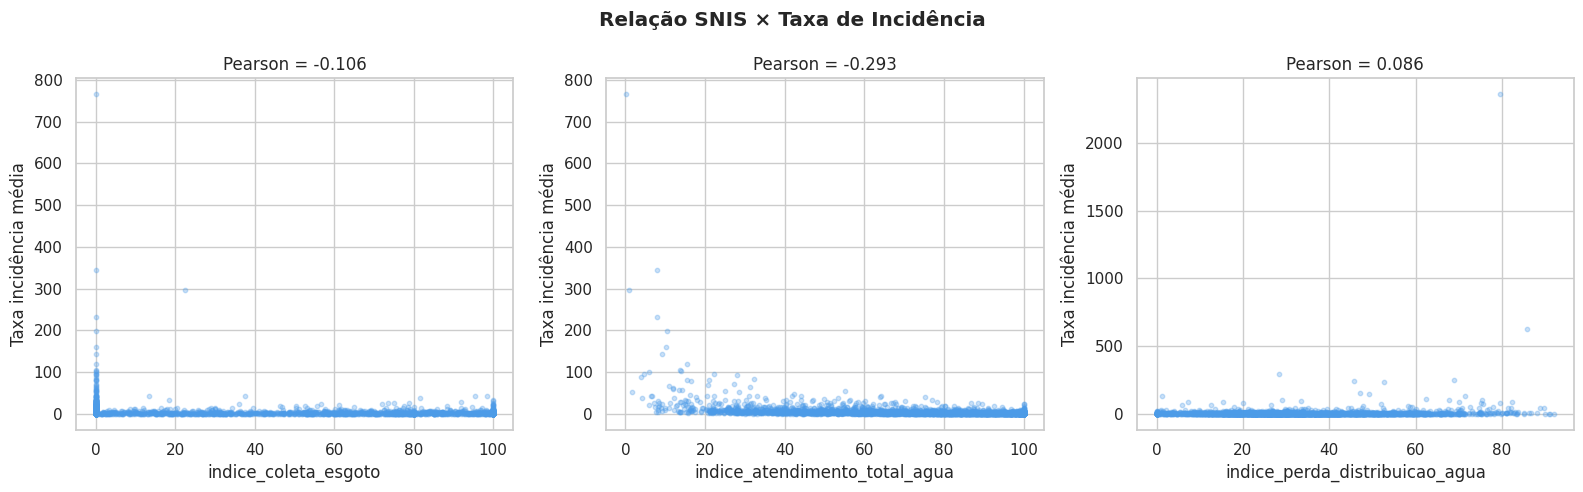

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pares = [
    ("indice_coleta_esgoto",           "indice_coleta_esgoto"),
    ("indice_atendimento_total_agua",  "indice_atendimento_total_agua"),
    ("indice_perda_distribuicao_agua", "indice_perda_distribuicao_agua"),
]

for ax, (col, label) in zip(axes, pares):
    sample = df_municipio_ano[[col, "taxa_incidencia_media"]].dropna().sample(
        n=min(3000, len(df_municipio_ano)), random_state=42
    )
    ax.scatter(sample[col], sample["taxa_incidencia_media"],
               alpha=0.3, s=10, color="#4C9BE8")
    ax.set_xlabel(label)
    ax.set_ylabel("Taxa incidência média")
    ax.set_title(f"Pearson = {sample[[col,'taxa_incidencia_media']].corr().iloc[0,1]:.3f}")

plt.suptitle("Relação SNIS × Taxa de Incidência", fontweight="bold")
plt.tight_layout()
plt.show()